In [2]:
# Import necessary libraries
import pandas as pd
import datetime
from openbb import obb
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, BaggingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Ticker and date range for stock data
ticker = "^GSPC"
start_date = datetime.datetime.now() - datetime.timedelta(days=365)
end_date = datetime.date.today()

start_date = start_date.strftime('%Y-%m-%d')
end_date = end_date.strftime('%Y-%m-%d')

In [4]:
df=obb.equity.price.historical(ticker, interval='1d',start_date=start_date,end_date= end_date,provider='yfinance').to_dataframe()

In [5]:
#print column names
print(df.columns)

Index(['open', 'high', 'low', 'close', 'volume', 'dividends', 'stock_splits'], dtype='object')


In [6]:
# Calculate additional features (SMA, Bollinger Bands, Donchian Channels)
for sma_period in [5, 10, 20, 50, 100, 200]:
    df[f'SMA_{sma_period}'] = df['close'].rolling(sma_period).mean()

In [7]:
# Add Bollinger Bands
for band in [10, 20]:
    df[f'BollingerBand_Up_{band}_2'] = df['close'].rolling(band).mean() + 2 * df['close'].rolling(band).std()
    df[f'BollingerBand_Down_{band}_2'] = df['close'].rolling(band).mean() - 2 * df['close'].rolling(band).std()

In [8]:
# Add Donchian Channels
for channel_period in [5, 10, 20, 50, 100, 200]:
    df[f'Donchian_Channel_Up_{channel_period}'] = df['high'].rolling(channel_period).max()
    df[f'Donchian_Channel_Down_{channel_period}'] = df['low'].rolling(channel_period).min()

In [9]:
# Prepare data for models
newdata = df[['close']].join(df.shift(1), rsuffix='_shifted')
newdata['target'] = newdata['close'].shift(-5)
newdata.dropna(inplace=True)

In [10]:

from sklearn.model_selection import train_test_split
# Split data into features and target variable
X = newdata.drop('target', axis=1)
Y = newdata['target']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [11]:
# Train and compare multiple models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'K Neighbors': KNeighborsRegressor(),
    'MLP Regressor': MLPRegressor(max_iter=5000),
    'Bagging Regressor': BaggingRegressor(),
    'AdaBoost Regressor': AdaBoostRegressor()
}

In [12]:
import warnings
warnings.filterwarnings("ignore")


from sklearn.model_selection import RandomizedSearchCV
# Train models and evaluate their performance
for name, model in models.items():
    if name in ['Random Forest', 'Gradient Boosting', 'MLP Regressor', 'Bagging Regressor', 'AdaBoost Regressor']:
        grid_search = RandomizedSearchCV(model, {}, cv=5, scoring="neg_mean_absolute_error")
        grid_search.fit(X_train, y_train)
        model = grid_search.best_estimator_
    else:
        model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    print(f"{name} MAE: {mae}")

Linear Regression MAE: 22.873813735439267


Random Forest MAE: 22.615707142857314
Gradient Boosting MAE: 19.646882168595962
K Neighbors MAE: 94.71200000000024
MLP Regressor MAE: 33566477.313317664
Bagging Regressor MAE: 28.324642857142994
AdaBoost Regressor MAE: 24.323550324675256


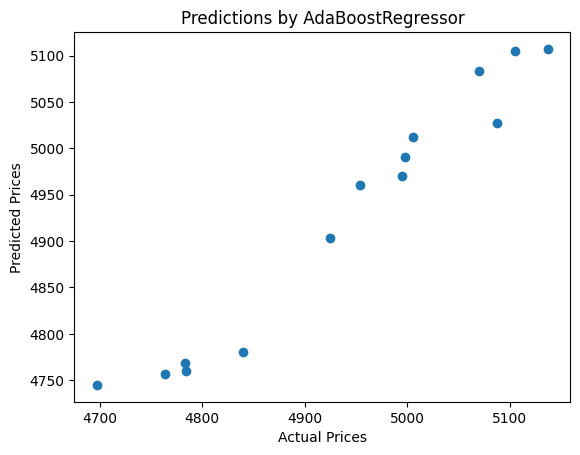

In [13]:
# Plot predictions of the best model
best_model = AdaBoostRegressor()
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title(f"Predictions by {best_model.__class__.__name__}")
plt.show()